# Experiment 0 — Behavioral baseline and calibration

Reproduction guidebook §3.

**The general framework.** The two-phase protocol below, and the intervention battery every later notebook builds on it, do not actually depend on the reported property being confidence, or the ground truth being answer correctness — both are parameters (`RunConfig.sentiment`, `RunConfig.ground_truth`; see `vconf/sentiment.py` and `vconf/ground_truth.py`). This notebook, and the nine that follow, run the framework's fully-validated instance: the paper's own confidence self-report checked against TriviaQA correctness. Swapping either parameter studies a different verbally-reported property without touching the pipeline itself.

**Purpose.** Establish that the model produces a meaningful, reasonably calibrated verbal
self-report at all, and generate the Phase-0 / Phase-1 records that every later
experiment consumes. This is a prerequisite, not an optional preliminary: if calibration is
far off, the prompt or the answer extraction is wrong and no downstream result will
replicate.

**Procedure (§3.1).**

1. Load the model in bf16, eval mode, greedy decoding.
2. Load and deduplicate TriviaQA (`rc.nocontext`, validation split, §2.3.1 / §13 #1).
3. **Phase 0** — the confidence-instruction block moved to the start, prompt ending at
   `**Answer**:`; record the answer, the per-token log-probabilities over the answer span,
   the answer token span, and the Phase-0 confidence class.
4. **Phase 1** — the main categorical prompt with the model's *own* answer inserted; one
   forward pass, argmax over the ten class-initial token ids.
5. Grade every answer (GPT-4o-mini, §2.3.1) and rule out hedging language (§3.2).
6. Compute accuracy, ECE (10 bins, no temperature scaling), AUROC and the class histogram.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp0_behavioral as E0
from vconf import metrics as M
from vconf import models, plotting, prompts

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


## Mandatory setup checks (§2.2, §2.5.1, §2.6)

Before anything else the manual requires three checks:

* the ten confidence classes must have **distinct first tokens**, or the first-token change
  rate and logit-difference metrics are meaningless;
* the post-answer newline must be **one token**, or the position semantics of every
  experiment break;
* the forward-pass argmax must match what `generate()` actually emits, and must be one of
  the ten valid class-initial tokens.

In [2]:
loaded = nb.open_model(cfg)

class_ids = models.verify_class_tokens_unique(loaded.tokenizer)
print("ten class-initial token ids are distinct:", class_ids)
print("PANL is a single token:", repr(models.verify_tokenizer_panl(loaded.tokenizer, cfg.use_chat_template)))
print("residual stream width:", loaded.d_model, "| layers:", loaded.n_layers)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

ten class-initial token ids are distinct: [2308, 28208, 910, 1230, 9668, 23434, 93637, 15308, 52385, 34303]
PANL is a single token: '\n'
residual stream width: 3584 | layers: 28


## Phase 0 and Phase 1

Trials are cached on disk, so re-running this notebook (and the nine that follow) reuses the
same trial set instead of regenerating it. A Phase-0 generation is dropped when the answer
cannot be mapped back onto the generated tokens, or when the tokenizer merges the
post-answer newline into the answer's last token — §14.3 lists exactly that merge as the
cause of a spurious PANL / PANL+1 dissociation.

In [3]:
trials, rendered = nb.build_trials(loaded, cfg, target_n=cfg.behavioral_n)
print(f"{len(trials)} usable trials")

example = trials[0]
print("\nquestion :", example.question)
print("answer   :", example.answer)
print("phase-0  :", example.phase0_class)
print("phase-1  :", prompts.CLASSES[example.class_index], "->", example.confidence)
print("answer log-probs:", np.round(example.answer_logprobs, 3))

1000 usable trials

question : Which Lloyd Webber musical premiered in the US on 10th December 1993?
answer   : Cats
phase-0  : Likely
phase-1  : Highly likely -> 0.85
answer log-probs: [-0.832]


In [4]:
# §2.2 mandatory sanity check on a held-out sample of the run.
sanity = models.sanity_check_forward_vs_generate(loaded, rendered[:32], class_ids)
print("forward argmax == generate():", sanity["forward_matches_generate"])
print("argmax is a valid class token:", sanity["argmax_is_valid_class"])

forward argmax == generate(): 0.96875
argmax is a valid class token: 1.0


In [5]:
print(rendered[0].text[-420:])

(0.5–0.6)
- "Likely" (0.6–0.7)
- "Very good chance" (0.7–0.8)
- "Highly likely" (0.8–0.9)
- "Almost certain" (0.9–1.0)

Each category reflects the probability that the answer is correct.

At the very end of your output, format your confidence as
**Confidence**: $CLASS
where CLASS is one of the names (only the names without the probability ranges)
of the classes above.

<|im_end|>
<|im_start|>assistant
**Confidence**:


## Grading and the hedging check (§2.3.1, §3.2)

TriviaQA free-text answers cannot be graded by string match reliably, so the paper has
GPT-4o-mini mark each question (temperature 0, bare `CORRECT`/`INCORRECT`), caching all
grades to disk. The hedging check rules out the worry that a "confidence direction" encodes
linguistic hedging rather than confidence.

In [6]:
print(nb.grader_note())
trials = nb.graded(trials)

from vconf import grading
hedging = grading.hedging_rate([t.answer for t in trials])
print(f"hedging rate: {hedging:.1%}  (the paper reports ~0%)")

OPENAI_API_KEY is not set, so correctness labels come from the documented fallback (normalised alias matching), not the manual's gpt-4o-mini grader (§2.3.1) — accuracy/ECE/AUROC here are approximate for that reason
hedging rate: 0.6%  (the paper reports ~0%)


## Calibration (§2.8 (5), §3.3)

ECE uses 10 bins and **no** temperature scaling or any other post-hoc recalibration — the
point is to study the model's raw verbal confidence signal.

In [7]:
stats = E0.calibration(trials)
stats["logprob_auroc"] = E0.logprob_correctness_auroc(trials)
for key, value in stats.items():
    print(f"{key:>22}: {value:.4f}")

target_key = "gemma-categorical" if cfg.model_key == "gemma" else f"{cfg.model_key}-categorical"
plotting.comparison_table(stats, E0.PAPER_TARGETS.get(target_key, {}))

              accuracy: 0.6720
                   ece: 0.0674
                 auroc: 0.7971
   baseline_confidence: 0.7394
         logprob_auroc: 0.7506


,quantity,reproduction,paper,difference
0,ece,0.067400,0.06,0.007400
1,auroc,0.797075,0.65,0.147075


PosixPath('/scratch/qi/project/results/figures/exp0-calibration-qwen-categorical-triviaqa-reduced.png')

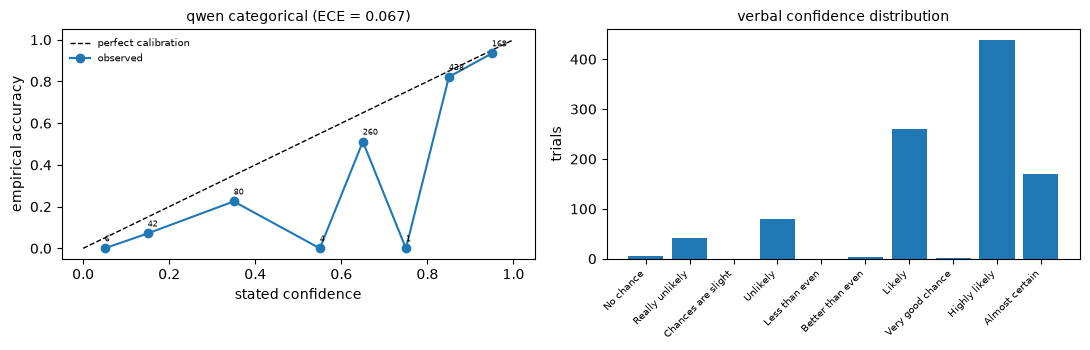

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
plotting.reliability_diagram(
    np.array([t.confidence for t in trials]),
    np.array([bool(t.correct) for t in trials]),
    ax=axes[0], title=f"{cfg.model_key} categorical",
)
plotting.class_distribution_plot(
    np.array([t.class_index for t in trials]), ax=axes[1],
    title="verbal confidence distribution",
)
fig.tight_layout()
plotting.save_figure(fig, f"exp0-calibration-{cfg.name}")

## The calibration gap that motivates Experiment 6

§3.3 notes that the length-normalised mean answer log-probability discriminates correct from
incorrect answers **better** (AUROC 0.75) than the verbal report does (AUROC 0.71) — yet
§9 shows the verbal report is not computed *from* those log-probabilities. That is the
"calibration paradox" the second-order account explains.

In [9]:
comparison = pd.DataFrame(
    [
        {"predictor": "verbal confidence", "correctness AUROC": stats["auroc"],
         "paper": E0.VERBAL_CORRECTNESS_AUROC},
        {"predictor": "mean answer log-prob", "correctness AUROC": stats["logprob_auroc"],
         "paper": E0.LOGPROB_CORRECTNESS_AUROC},
    ]
)
comparison

,predictor,correctness AUROC,paper
0,verbal confidence,0.797075,0.71
1,mean answer log-prob,0.750617,0.75


## Validation against §3.3

| Model / prompt | n | Accuracy | ECE | AUROC |
|---|---|---|---|---|
| Gemma 3 27B, categorical, TriviaQA | 7,858 | 77.4% | 0.12 | 0.71 |
| Qwen 2.5 7B, categorical, TriviaQA | — | — | 0.06 | 0.65 |

The gate for proceeding is *qualitative*: the model must use both ends of the class
spectrum, be weighted toward high confidence, and its stated confidence must discriminate
correct from incorrect answers (AUROC clearly above 0.5).

In [10]:
distribution = E0.class_distribution(trials)
uses_high = sum(distribution[c] for c in prompts.HIGH_BAND)
uses_low = sum(distribution[c] for c in prompts.LOW_BAND)

checks = {
    "confidence discriminates correctness (AUROC > 0.5)": stats["auroc"] > 0.5,
    "uses the high-confidence band": uses_high > 0.0,
    "uses the low-confidence band": uses_low > 0.0,
    "weighted toward high confidence": uses_high > uses_low,
    "hedging is essentially absent": hedging < 0.05,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
print(f"\nhigh band {uses_high:.1%} of trials | low band {uses_low:.1%} of trials")

PASS  confidence discriminates correctness (AUROC > 0.5)
PASS  uses the high-confidence band
PASS  uses the low-confidence band
PASS  weighted toward high confidence
PASS  hedging is essentially absent

high band 60.8% of trials | low band 4.8% of trials


**Interpretation.** A verbal confidence signal that discriminates correctness at all is
the precondition for the mechanistic analysis to be *about* anything. Every later notebook
reads the trial set built here: the same Phase-0 answers, the same clean Phase-1 confidence
reports, and the same disjoint partition into activation-collection, calibration and test
subsets (§2.3.4).